# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
|Jonathan Joyo Wibowo|5054251026|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [70]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from google.colab import drive

SEED = 67

In [44]:
# Mount drive ke filesystem vm google collab, soalnya dataset di gdrive
uploaded = drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

In [46]:
data = pd.read_csv('/content/drive/MyDrive/dataset/wine/WineQT.csv')

# Data Cleaning

# Hapus duplikat
data = data.drop(["Id"], axis=1, errors="ignore")
dup = data.duplicated()
dup_row = dup[dup].index
data = data.drop(dup_row, axis=0, errors="ignore")

dup = data.duplicated()
dup[dup]

,0


In [47]:
#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.
print(data.head())
print(data.info())
print(data.describe())

data.groupby("quality").count()
data[(data["quality"] >= 3) & (data["quality"] <= 5)]
data[(data["quality"] < 4) | (data["quality"] > 7)]
#! Cari fungsi-fungsi yang dapat digunakan untuk menampilkan informasi yang diinginkan.

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  alcohol  quality
0            7.4              0.70         0.00             1.9      0.076                 11.0                  34.0   0.9978  3.51       0.56      9.4        5
1            7.8              0.88         0.00             2.6      0.098                 25.0                  67.0   0.9968  3.20       0.68      9.8        5
2            7.8              0.76         0.04             2.3      0.092                 15.0                  54.0   0.9970  3.26       0.65      9.8        5
3           11.2              0.28         0.56             1.9      0.075                 17.0                  60.0   0.9980  3.16       0.58      9.8        6
5            7.4              0.66         0.00             1.8      0.075                 13.0                  40.0   0.9978  3.51       0.56      9.4        5
<class 'pandas.core.frame.Da

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
190,7.9,0.350,0.46,3.6,0.078,15.0,37.0,0.99730,3.35,0.86,12.80,8
197,10.3,0.320,0.45,6.4,0.073,5.0,13.0,0.99760,3.23,0.82,12.60,8
271,5.6,0.850,0.05,1.4,0.045,12.0,88.0,0.99240,3.56,0.82,12.90,8
310,12.6,0.310,0.72,2.2,0.072,6.0,29.0,0.99870,2.88,0.82,9.80,8
321,11.3,0.620,0.67,5.2,0.086,6.0,19.0,0.99880,3.22,0.69,13.40,8
324,11.6,0.580,0.66,2.2,0.074,10.0,47.0,1.00080,3.25,0.57,9.00,3
340,9.4,0.300,0.56,2.8,0.080,6.0,17.0,0.99640,3.15,0.92,11.70,8
349,10.7,0.350,0.53,2.6,0.070,5.0,16.0,0.99720,3.15,0.65,11.00,8
368,10.4,0.610,0.49,2.1,0.200,5.0,16.0,0.99940,3.16,0.63,8.40,3
419,5.0,0.420,0.24,2.0,0.060,19.0,50.0,0.99170,3.72,0.74,14.00,8


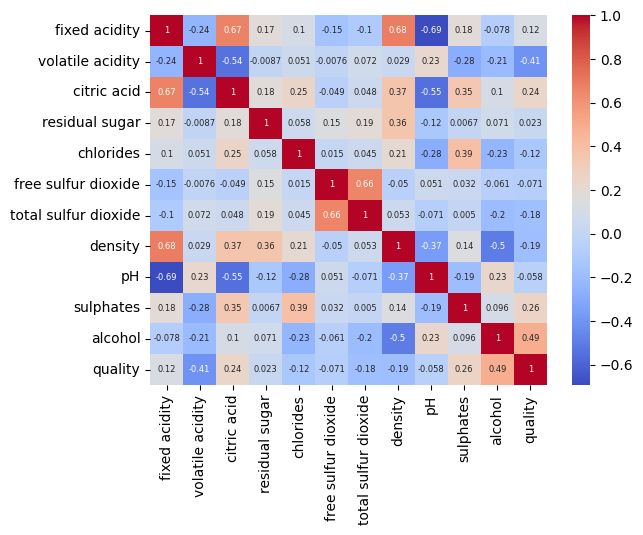

In [48]:
# Tampilkan Korelasi Matrix
sns.heatmap(data.corr(), annot=True, annot_kws={"size": 6}, cmap="coolwarm")
plt.show()

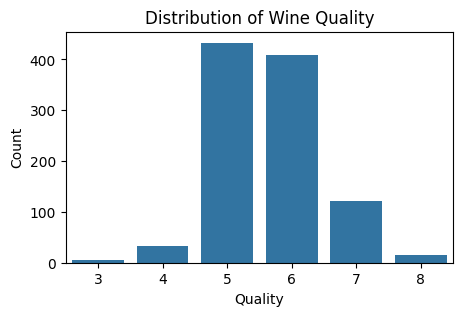

In [49]:
# Tampilkan distribusi label (quality) dalam bentuk visualisasi, misalnya menggunakan histogram atau bar plot.
plt.figure(figsize=(5, 3))
sns.countplot(x="quality", data=data)
plt.title("Distribution of Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()

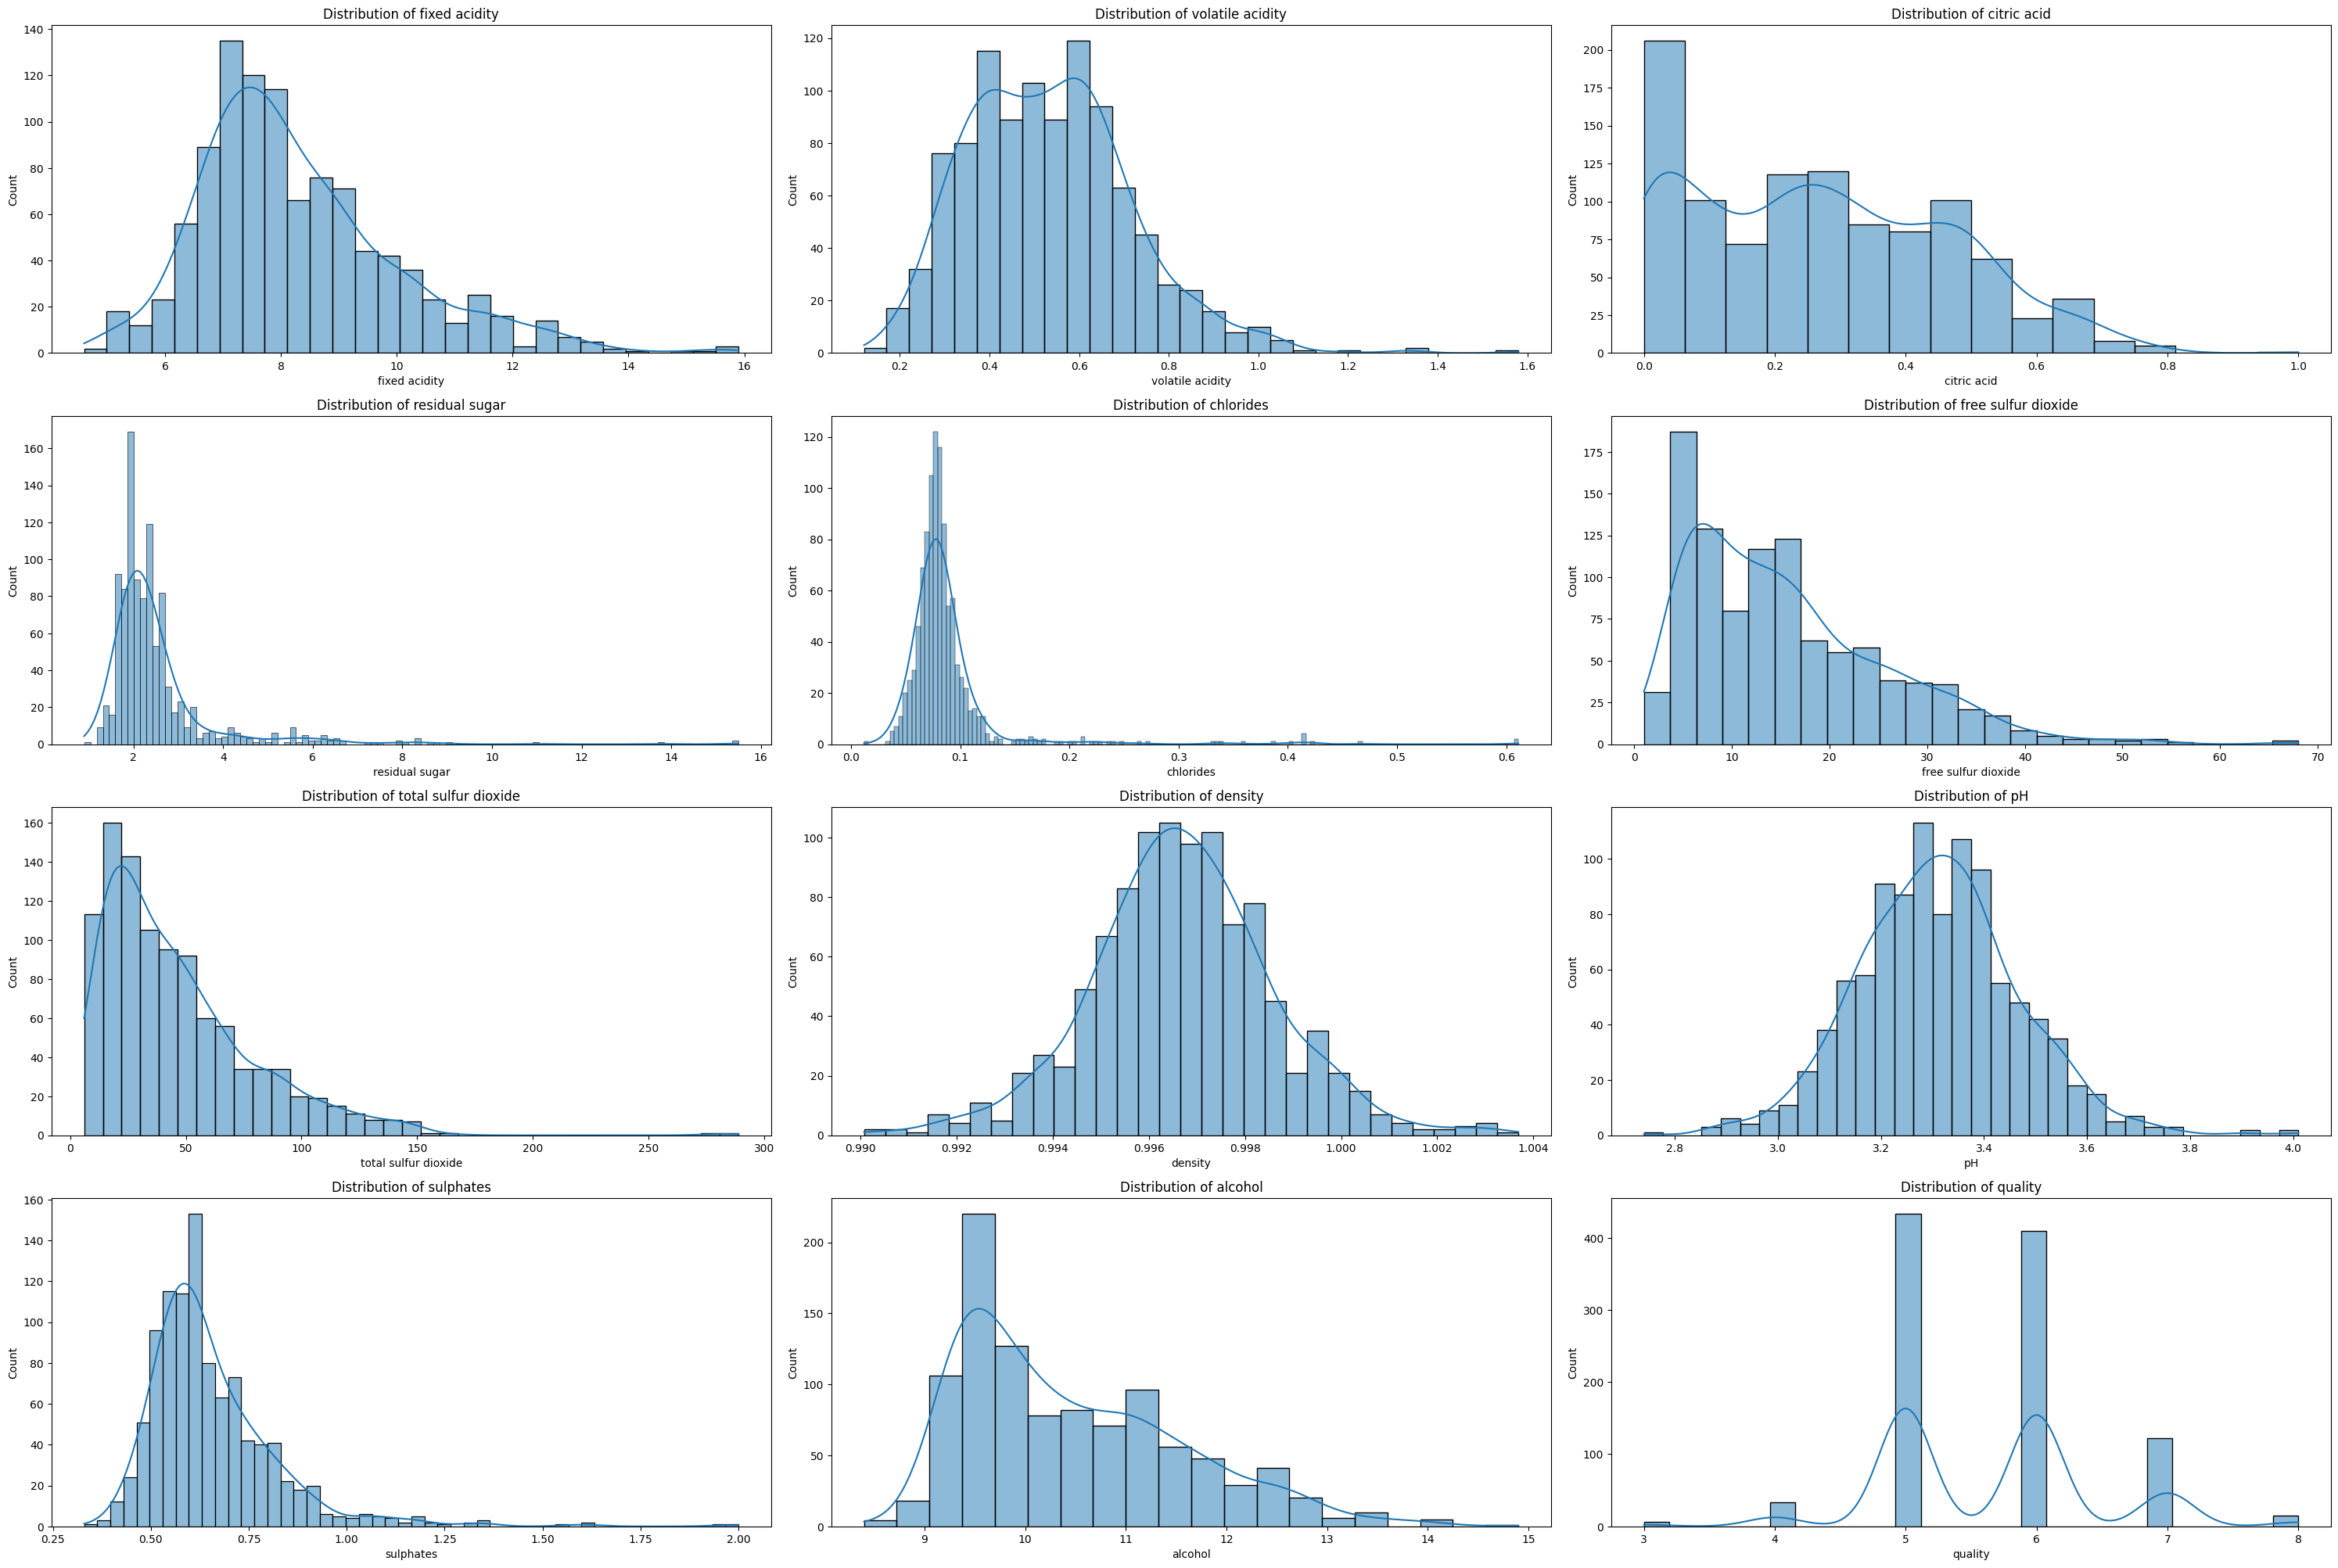

In [50]:
n_features = len(data)
n_cols = 3
n_rows = (n_features // n_cols) + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 10, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(data):
    sns.histplot(data=data,
                 x=col,
                 kde=True,
                 ax=axes[i])

    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(f"{col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

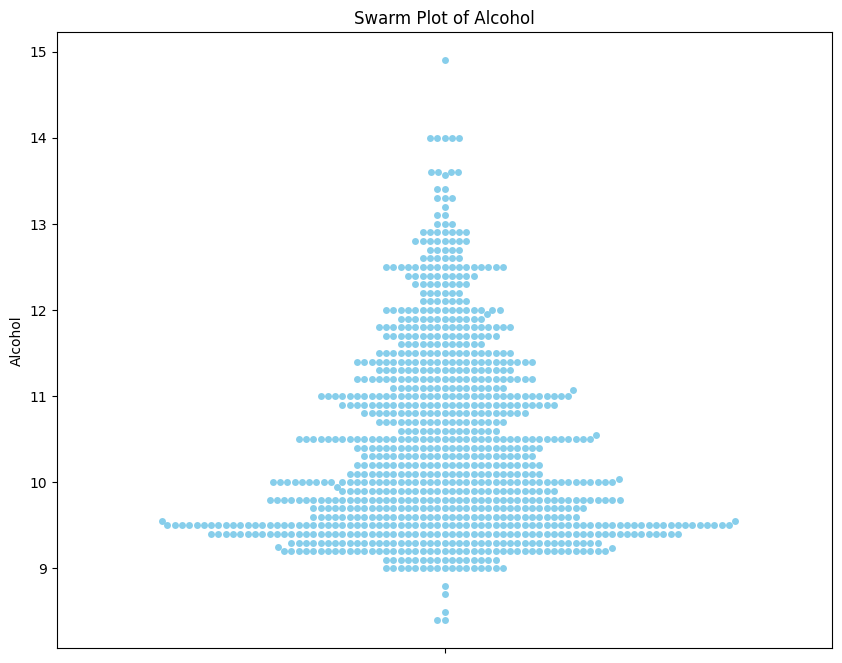

In [51]:
plt.figure(figsize=(10, 8))

sns.swarmplot(y="alcohol", data=data, color='skyblue')

plt.title('Swarm Plot of Alcohol')
plt.ylabel('Alcohol')
plt.show()

## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan.

# 2. Preprocessing




In [52]:
class OutlierDropper(BaseEstimator, TransformerMixin):
  def fit(self, x, y=None):
    return self

  def transform(self, x):
    x_copy = x.copy()
    columns = x.columns.drop(["quality"])

    for col in columns:
      q1, q3 = x[col].quantile(0.25), x[col].quantile(0.75)
      iqr = q3 - q1
      lower_whisker, upper_whisker = q1 - 1.5 * iqr, q3 + 1.5 * iqr
      x_copy = x_copy[(x_copy[col] <= upper_whisker) & (x_copy[col] >= lower_whisker)]

    return x_copy

In [53]:
outlier_pipeline = Pipeline([("outlierdropper", OutlierDropper())])

In [54]:
with_outlier_data = data.copy()
without_outlier_data = outlier_pipeline.fit_transform(data)

without_outlier_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 756 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         756 non-null    float64
 1   volatile acidity      756 non-null    float64
 2   citric acid           756 non-null    float64
 3   residual sugar        756 non-null    float64
 4   chlorides             756 non-null    float64
 5   free sulfur dioxide   756 non-null    float64
 6   total sulfur dioxide  756 non-null    float64
 7   density               756 non-null    float64
 8   pH                    756 non-null    float64
 9   sulphates             756 non-null    float64
 10  alcohol               756 non-null    float64
 11  quality               756 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 76.8 KB


<Axes: xlabel='quality', ylabel='alcohol'>

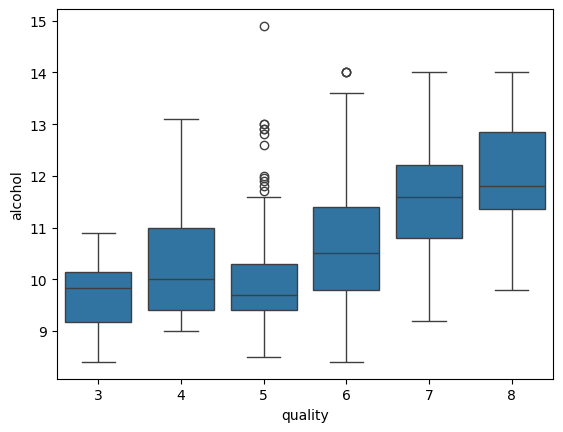

In [55]:
# Periksa Outliers (jika diperlukan), misalnya menggunakan boxplot atau metode statistik lainnya. (Bisa dilakukan eksperimen dengan dan tanpa outlier untuk melihat perbedaan performa model)
sns.boxplot(data=data, x="quality", y="alcohol")


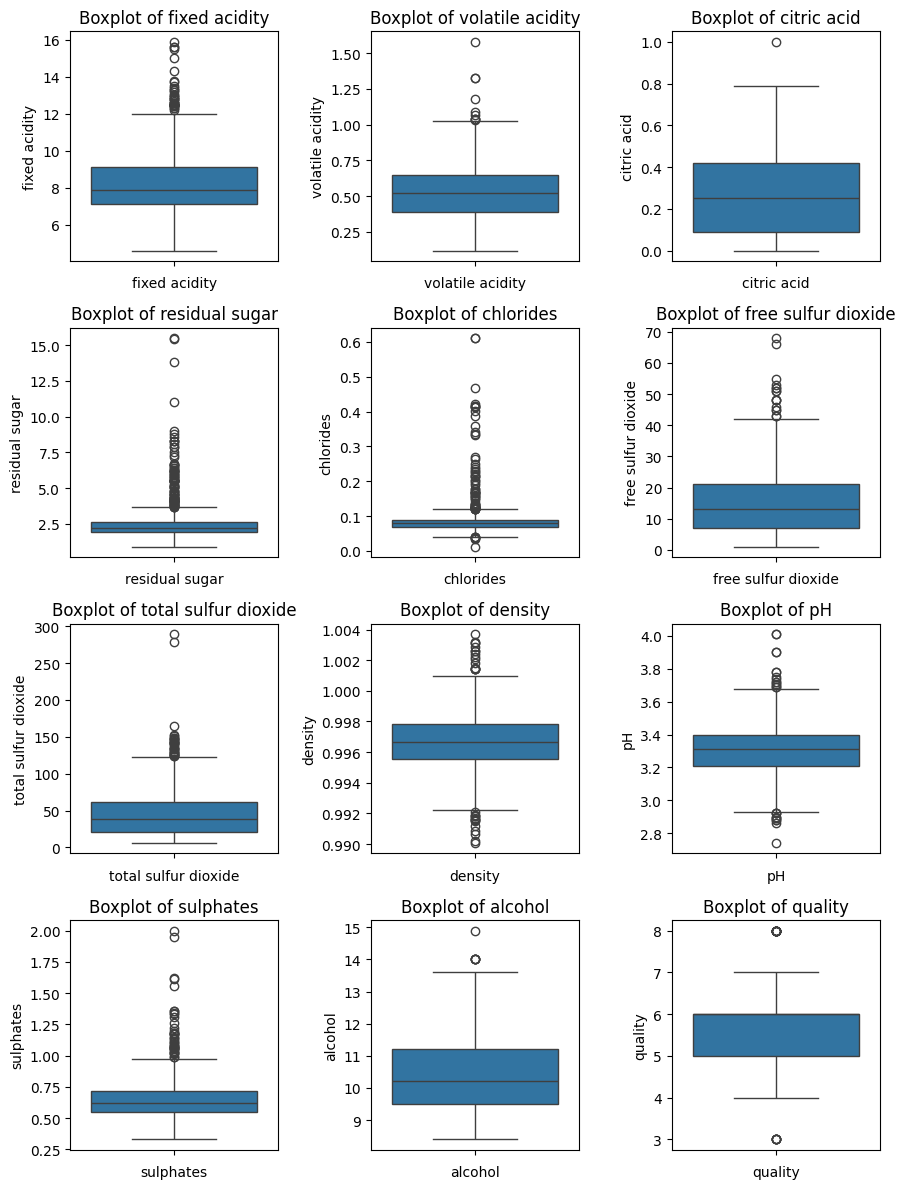

In [56]:
n_rows, n_cols = 4, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(with_outlier_data):
    ax = sns.boxplot(data=with_outlier_data,
                 y=col,
                 ax=axes[i])

    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel(f"{col}")

plt.tight_layout()
plt.show()

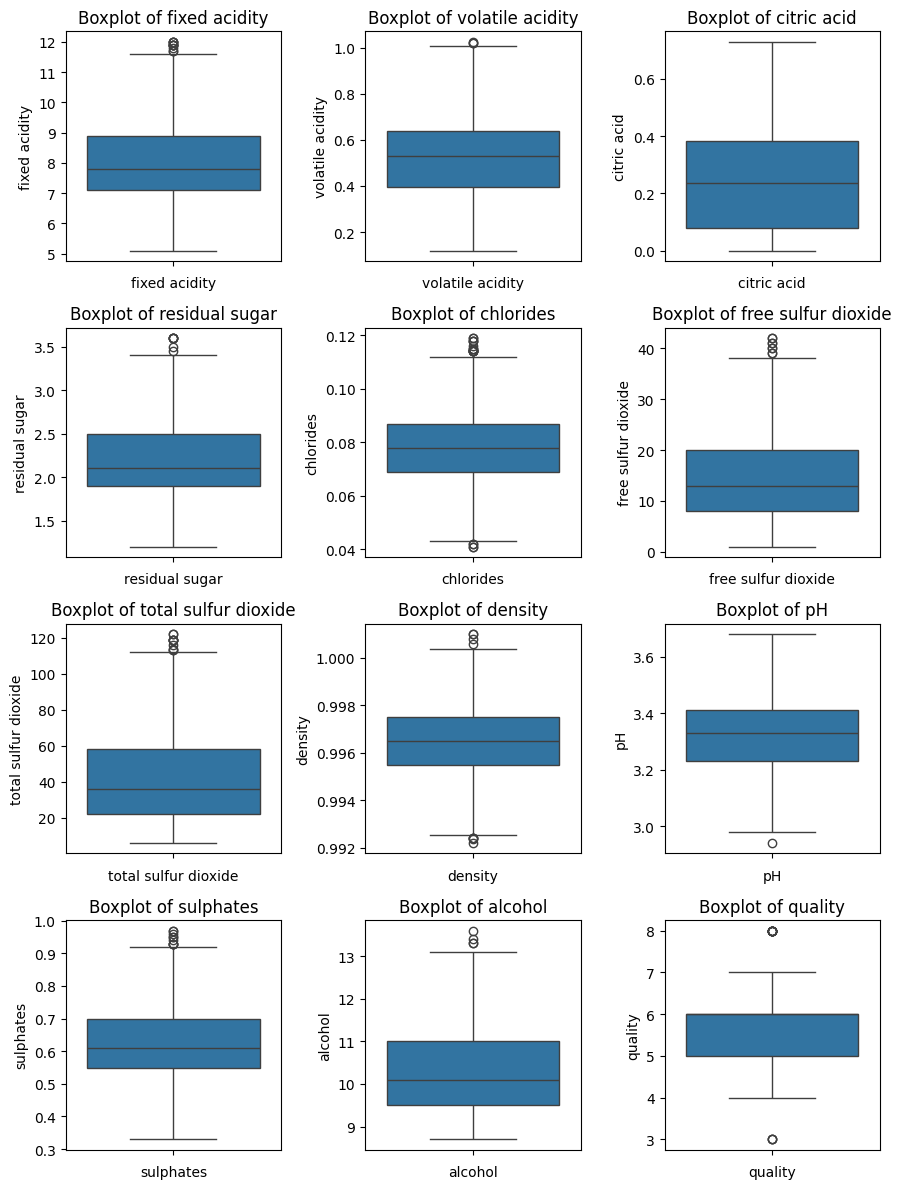

In [57]:
n_rows, n_cols = 4, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(without_outlier_data):
    ax = sns.boxplot(data=without_outlier_data,
                 y=col,
                 ax=axes[i])

    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel(f"{col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [58]:
# PISAHKAN DATA MENJADI TRAIN DATA DAN SPLIT DATA DENGAN RASIO 1:4

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
with_outlier_train_data, with_outlier_test_data = None, None
without_outlier_train_data, without_outlier_test_data = None, None

for train_idx, test_idx in split.split(with_outlier_data, with_outlier_data["quality"]):
  with_outlier_train_data = with_outlier_data.iloc[train_idx]
  with_outlier_test_data = with_outlier_data.iloc[test_idx]

for train_idx, test_idx in split.split(without_outlier_data, without_outlier_data["quality"]):
  without_outlier_train_data = without_outlier_data.iloc[train_idx]
  without_outlier_test_data = without_outlier_data.iloc[test_idx]

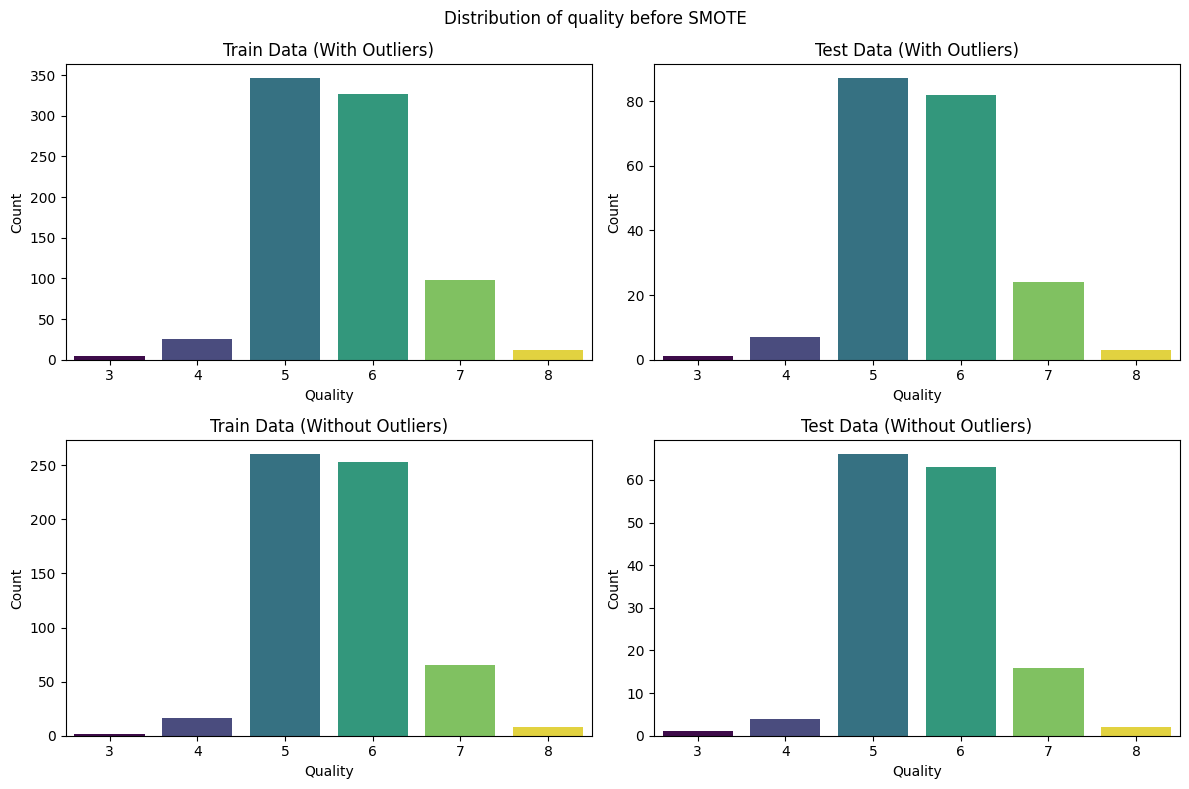

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Distribution of quality before SMOTE")

datasets = {
    (0, 0): ("Train Data (With Outliers)", with_outlier_train_data),
    (0, 1): ("Test Data (With Outliers)", with_outlier_test_data),
    (1, 0): ("Train Data (Without Outliers)", without_outlier_train_data),
    (1, 1): ("Test Data (Without Outliers)", without_outlier_test_data)
}

for (row, col), (title, df) in datasets.items():
    sns.countplot(data=df,
                  x="quality",
                  ax=axes[row, col],
                  hue="quality",
                  legend=False,
                  palette="viridis")

    axes[row, col].set_title(title)
    axes[row, col].set_xlabel("Quality")
    axes[row, col].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [60]:
# PISAHKAN FITUR DAN TARGET (quality)

smote_with_outlier_train_data = with_outlier_train_data.copy()
smote_without_outlier_train_data = without_outlier_train_data.copy()


# TRAIN DATA
# DENGAN SMOTE DENGAN OUTLIER
x_smote_with_outlier_train_data = smote_with_outlier_train_data.drop(columns=["quality"], axis=1)
y_smote_with_outlier_train_data = smote_with_outlier_train_data["quality"]

# DENGAN SMOTE TANPA OUTLIER
x_smote_without_outlier_train_data = smote_without_outlier_train_data.drop(columns=["quality"], axis=1)
y_smote_without_outlier_train_data = smote_without_outlier_train_data["quality"]

# TANPA SMOTE DENGAN OUTLIER
x_with_outlier_train_data = with_outlier_train_data.drop(columns=["quality"], axis=1)
y_with_outlier_train_data = with_outlier_train_data["quality"]

# TANPA SMOTE TANPA OUTLIER
x_without_outlier_train_data = without_outlier_train_data.drop(columns=["quality"], axis=1)
y_without_outlier_train_data = without_outlier_train_data["quality"]


# TEST DATA
# DENGAN OUTLIER
x_with_outlier_test_data = with_outlier_test_data.drop(columns=["quality"], axis=1)
y_with_outlier_test_data = with_outlier_test_data["quality"]

x_without_outlier_test_data = without_outlier_test_data.drop(columns=["quality"], axis=1)
y_without_outlier_test_data = without_outlier_test_data["quality"]

In [61]:
# LAKUKAN SMOTE UNTUK MENANGANI DATA IMBALANCE
without_outlier_train_data.copy()
smote = SMOTE(random_state=SEED, k_neighbors=1)

x_smote_with_outlier_train_data, y_smote_with_outlier_train_data = smote.fit_resample(x_smote_with_outlier_train_data, y_smote_with_outlier_train_data)
x_smote_without_outlier_train_data, y_smote_without_outlier_train_data = smote.fit_resample(x_smote_without_outlier_train_data, y_smote_without_outlier_train_data)

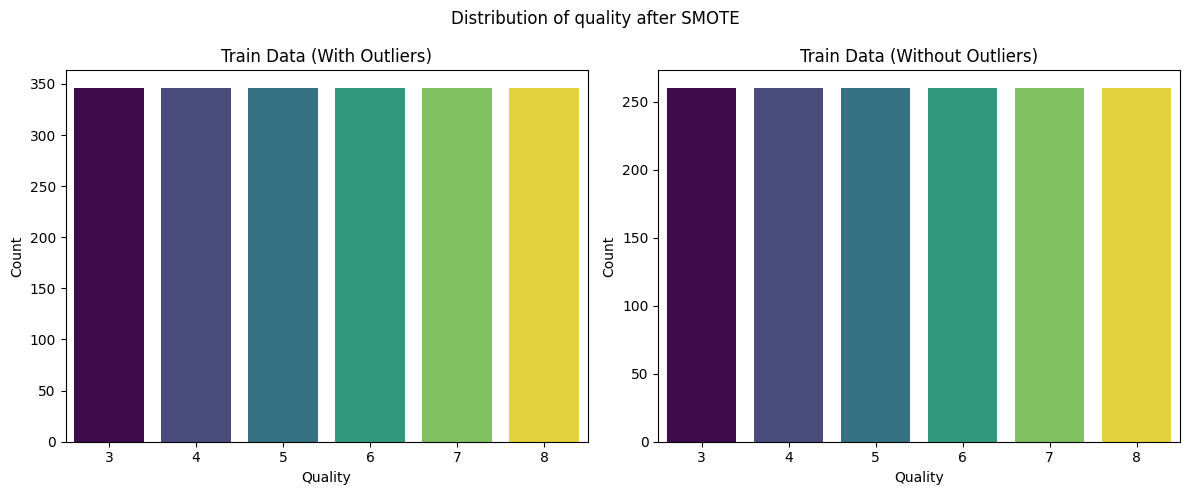

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Distribution of quality after SMOTE")

datasets = {
    0: ("Train Data (With Outliers)", y_smote_with_outlier_train_data),
    1: ("Train Data (Without Outliers)", y_smote_without_outlier_train_data)
}

for idx, (title, series) in datasets.items():
    sns.countplot(
        x=series,
        ax=axes[idx],
        hue=series,
        legend=False,
        palette="viridis")

    axes[idx].set_title(title)
    axes[idx].set_xlabel("Quality")
    axes[idx].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [63]:
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler. (Bisa dilakukan eksperimen dengan dan tanpa scaling untuk melihat perbedaan performa model)
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.

# DATA TRAINING
smote_with_outlier_scaler = StandardScaler()
x_smote_with_outlier_train_data = smote_with_outlier_scaler.fit_transform(x_smote_with_outlier_train_data)
y_smote_with_outlier_train_data = y_smote_with_outlier_train_data

smote_without_outlier_scaler = StandardScaler()
x_smote_without_outlier_train_data = smote_without_outlier_scaler.fit_transform(x_smote_without_outlier_train_data)
y_smote_without_outlier_train_data = y_smote_without_outlier_train_data

with_outlier_scaler = StandardScaler()
x_with_outlier_train_data = with_outlier_scaler.fit_transform(x_with_outlier_train_data)
y_with_outlier_train_data = y_with_outlier_train_data

without_outlier_scaler = StandardScaler()
x_without_outlier_train_data = without_outlier_scaler.fit_transform(x_without_outlier_train_data)
y_without_outlier_train_data = y_without_outlier_train_data


# DATA TESTING
x_smote_with_outlier_test_data = smote_with_outlier_scaler.transform(x_with_outlier_test_data)
y_smote_with_outlier_test_data = y_with_outlier_test_data

x_smote_without_outlier_test_data = smote_without_outlier_scaler.transform(x_without_outlier_test_data)
y_smote_without_outlier_test_data = y_without_outlier_test_data

x_with_outlier_test_data = with_outlier_scaler.transform(x_with_outlier_test_data)
y_with_outlier_test_data = y_with_outlier_test_data

x_without_outlier_test_data = without_outlier_scaler.transform(x_without_outlier_test_data)
y_without_outlier_test_data = y_without_outlier_test_data


# 3. Eksperimen Model KNN


In [69]:
# KEMUNGKINAN HYPER PARAMETER
k_values = range(1, 12)
metrics = ["euclidean", "manhattan"]

# KEMUNGKINAN DATASET
datasets = {
    "With Outliers & SMOTE": (
        x_smote_with_outlier_train_data,
        y_smote_with_outlier_train_data,
        x_smote_with_outlier_test_data,
        y_smote_with_outlier_test_data
    ),
    "Without Outliers & SMOTE": (
        x_smote_without_outlier_train_data,
        y_smote_without_outlier_train_data,
        x_smote_without_outlier_test_data,
        y_smote_without_outlier_test_data
    ),
    "With Outliers": (
        x_with_outlier_train_data,
        y_with_outlier_train_data,
        x_with_outlier_test_data,
        y_with_outlier_test_data
    ),
    "Without Outliers": (
        x_without_outlier_train_data,
        y_without_outlier_train_data,
        x_without_outlier_test_data,
        y_without_outlier_test_data
    )
}

# COBA SETIAP KOMBINASI DATASET DAN HYPER PARAMETER
results = []

for dataset_name, (x_train, y_train, x_test, y_test) in datasets.items():
    for k in k_values:
        for metric in metrics:
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
            knn.fit(x_train, y_train)

            y_pred = knn.predict(x_test)

            results.append({
                "Dataset": dataset_name,
                "k": k,
                "Metric": metric,
                "Accuracy": accuracy_score(y_test, y_pred),
                "Macro F1": f1_score(y_test, y_pred, average="macro", zero_division=0),
                "Weighted F1": f1_score(y_test, y_pred, average="weighted", zero_division=0)
            })

# HASIL BRUTE FORCE
df_results = pd.DataFrame(results)
#df_results.sort_values(by="Macro F1", ascending=False).head(10)
df_results.sort_values(by="Accuracy", ascending=False).head(20)

,Dataset,k,Metric,Accuracy,Macro F1,Micro F1,Weighted F1
85,Without Outliers,10,manhattan,0.710526,0.319118,0.710526,0.685294
87,Without Outliers,11,manhattan,0.703947,0.316667,0.703947,0.678909
81,Without Outliers,8,manhattan,0.684211,0.317972,0.684211,0.662837
86,Without Outliers,11,euclidean,0.671053,0.294684,0.671053,0.644529
84,Without Outliers,10,euclidean,0.651316,0.286135,0.651316,0.626744
79,Without Outliers,7,manhattan,0.651316,0.275498,0.651316,0.625263
83,Without Outliers,9,manhattan,0.644737,0.286142,0.644737,0.622954
72,Without Outliers,4,euclidean,0.638158,0.312676,0.638158,0.624962
77,Without Outliers,6,manhattan,0.638158,0.298533,0.638158,0.623921
75,Without Outliers,5,manhattan,0.631579,0.281851,0.631579,0.611210


# 4. Evaluasi Model


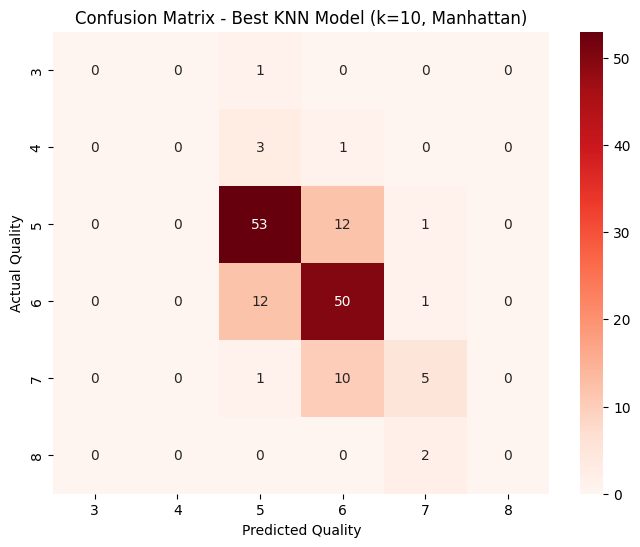


Classification Report:

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         4
           5       0.76      0.80      0.78        66
           6       0.68      0.79      0.74        63
           7       0.56      0.31      0.40        16
           8       0.00      0.00      0.00         2

    accuracy                           0.71       152
   macro avg       0.33      0.32      0.32       152
weighted avg       0.67      0.71      0.69       152



In [74]:
# Tampilkan evaluasi model KNN dengan metriks evaluasi yang sesuai dengan tipe masalah klasifikasi

model = KNeighborsClassifier(n_neighbors=10, metric="manhattan")
model.fit(x_without_outlier_train_data, y_without_outlier_train_data)

y_pred = model.predict(x_without_outlier_test_data)
y_true = y_without_outlier_test_data

cm = confusion_matrix(y_true, y_pred)
labels = np.unique(y_true)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Confusion Matrix - Best KNN Model (k=10, Manhattan)")
plt.xlabel("Predicted Quality")
plt.ylabel("Actual Quality")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, zero_division=0))


# 5. Analisis

Berdasarkan hasil experiment, bisa dilihat bahwa model yang menghasilkan akurasi paling besar itu yang menggunakan dataset tanpa outlier dengan hyperparameter 10 neighbor dan metric manhattan

Tapi, kalo dilihat dari confusion matrix dan classification report, sepertinya kebanyakan dari akurasi yang didapat itu dari memprediksi wine dengan kualitas 5 & 6 yang mana itu adalah data mayoritas, sedangkan wine yang memiliki kualitas minoritas seperti 3 & 8 itu tidak ada yang berhasil diprediksi.

Jadi model ini (dan model-model lain yang menggunakan dataset tanpa outlier) bisa memiliki akurasi yang tinggi karena data-data yang susah diprediksi seperti kualitas 3 & 8 tadi kebanyakan sudah dibuang, jadi tinggal tersisa data yang mudah diprediksi.

Dan juga kalo dilihat dari hasil dari berbagai model yang dicoba, kita tahu bahwa SMOTE tidak membantu, malah sebaliknya, kebanyakan model yang data trainnya menggunakan SMOTE untuk mengatasi imbalance justru memiliki akurasi yang rendah.

Macro_F1 dari semua model juga relatif rendah, maksnya cuma di 31%, ini menandakan bahwa semua model (tidak hanya yang data outliernya dihapus) juga memiliki kesulitan dalam memprediksi data minoritas.

# 6. Kesimpulan dan Saran

1. Mencari cara untuk mengatasi imbalance data dengan benar
2. Menggunakan dataset di kaggle yang ada data terpisah untuk tesnya, jadi kita tau kebenaran dari akurasi suatu model